# Neural Training Curves

Loss curves and validation behavior for the rolling-feature neural models.


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

LOG_DIR = PROJECT_ROOT / "logs"

REPORTS = {
    "MLP rolling": LOG_DIR / "train_mlp_rolling_report.json",
    "GRU+MLP rolling": LOG_DIR / "train_gru_mlp_rolling_report.json",
    "Online MLP rolling": LOG_DIR / "train_online_mlp_rolling_report.json",
    "Online GRU+MLP rolling": LOG_DIR / "train_online_gru_mlp_rolling_report.json",
}

BASELINE_SCORES = {
    "Rolling XGBoost": 0.005567144781773781,
    "Rolling LightGBM": 0.004498237911223724,
}


def plot_grouped_lines(ax, df, x, y, group, marker="o", max_groups=None):
    groups = list(df[group].dropna().unique())
    if max_groups is not None:
        groups = groups[:max_groups]
    for name in groups:
        part = df[df[group] == name].sort_values(x)
        ax.plot(part[x], part[y], marker=marker, label=str(name))
    ax.legend(fontsize=8)


def grouped_barh(df, label_col, value_col, hue_col=None, title=None):
    if hue_col is None:
        plot_df = df.sort_values(value_col)
        plt.figure(figsize=(10, max(4, len(plot_df) * 0.35)))
        plt.barh(plot_df[label_col].astype(str), plot_df[value_col])
        plt.axvline(0, color="black", linewidth=1)
        plt.title(title or value_col)
        plt.tight_layout()
        return

    pivot = df.pivot_table(index=label_col, columns=hue_col, values=value_col, aggfunc="first").fillna(0)
    pivot = pivot.loc[pivot.max(axis=1).sort_values().index]
    ax = pivot.plot(kind="barh", figsize=(11, max(4, len(pivot) * 0.35)))
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(title or value_col)
    plt.tight_layout()

print({name: path.exists() for name, path in REPORTS.items()})


{'MLP rolling': True, 'GRU+MLP rolling': True, 'Online MLP rolling': True, 'Online GRU+MLP rolling': True}


In [2]:
SWEEP_DIR = PROJECT_ROOT / "models" / "neural" / "regularized_mlp_sweep"
SWEEP_HISTORY_PATH = SWEEP_DIR / "history.csv"
SWEEP_SUMMARY_PATH = SWEEP_DIR / "summary.csv"
SWEEP_REPORT_PATH = LOG_DIR / "train_regularized_mlp_sweep_report.json"

print({
    "regularized_sweep_history": SWEEP_HISTORY_PATH.exists(),
    "regularized_sweep_summary": SWEEP_SUMMARY_PATH.exists(),
    "regularized_sweep_report": SWEEP_REPORT_PATH.exists(),
})


{'regularized_sweep_history': True, 'regularized_sweep_summary': True, 'regularized_sweep_report': True}


In [3]:
def load_report(name, path):
    if not path.exists():
        return None
    report = json.loads(path.read_text())
    history = pd.DataFrame(report.get("history", []))
    if not history.empty:
        history.insert(0, "model", name)
    return report, history

reports = {}
history_frames = []

for name, path in REPORTS.items():
    loaded = load_report(name, path)
    if loaded is None:
        print(f"missing: {path}")
        continue
    report, history = loaded
    reports[name] = report
    if not history.empty:
        history_frames.append(history)

history_df = pd.concat(history_frames, ignore_index=True) if history_frames else pd.DataFrame()
history_df


,model,epoch,train_loss,valid_weighted_r2,static_valid_weighted_r2
0,MLP rolling,1,0.643636,-0.003860,NaN
1,MLP rolling,2,0.634741,-0.010503,NaN
2,MLP rolling,3,0.629446,-0.018832,NaN
3,MLP rolling,4,0.624313,-0.028420,NaN
4,MLP rolling,5,0.618050,-0.037015,NaN
5,MLP rolling,6,0.612541,-0.053821,NaN
6,MLP rolling,7,0.606051,-0.069263,NaN
7,MLP rolling,8,0.599860,-0.068561,NaN
8,GRU+MLP rolling,1,0.637028,-0.012707,NaN
9,GRU+MLP rolling,2,0.614381,-0.031097,NaN


In [4]:
score_rows = []
for model, report in reports.items():
    score_rows.append({
        "model": model,
        "valid_r2": report.get("valid_weighted_r2", report.get("valid_online_weighted_r2")),
        "test_r2": report.get("test_weighted_r2", report.get("test_online_weighted_r2")),
        "best_epoch": report.get("best_epoch"),
        "elapsed_minutes": report.get("elapsed_seconds", np.nan) / 60,
    })

for model, valid_r2 in BASELINE_SCORES.items():
    score_rows.append({
        "model": model,
        "valid_r2": valid_r2,
        "test_r2": np.nan,
        "best_epoch": np.nan,
        "elapsed_minutes": np.nan,
    })

score_df = pd.DataFrame(score_rows).sort_values("valid_r2", ascending=False)
score_df


,model,valid_r2,test_r2,best_epoch,elapsed_minutes
4,Rolling XGBoost,0.005567,NaN,NaN,NaN
5,Rolling LightGBM,0.004498,NaN,NaN,NaN
0,MLP rolling,-0.003860,-0.006744,1.0,7.719705
1,GRU+MLP rolling,-0.012707,-0.014378,1.0,8.888222
3,Online GRU+MLP rolling,-0.105476,-0.082004,NaN,8.809893
2,Online MLP rolling,-0.146223,-0.062946,NaN,6.843241


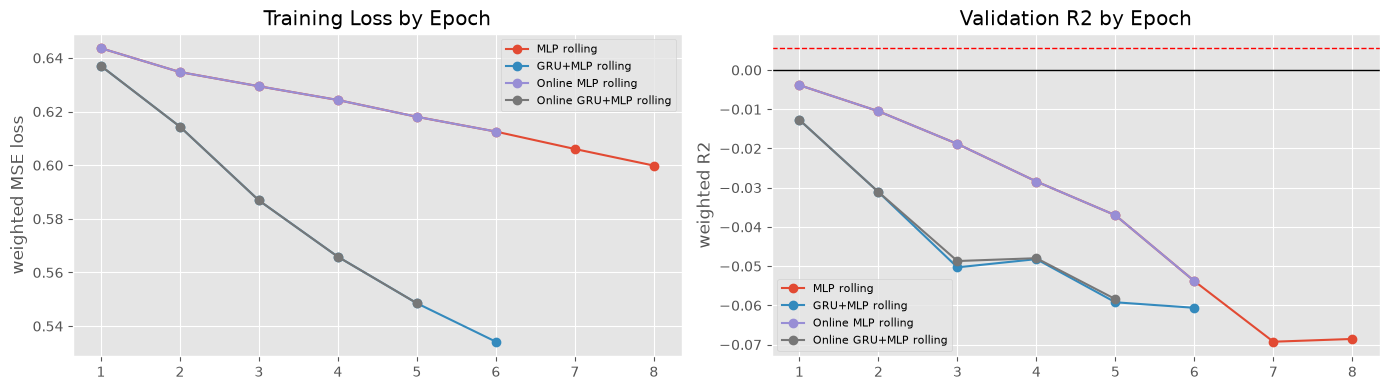

In [5]:
if not history_df.empty:
    loss_col = "train_loss"
    r2_col = "valid_weighted_r2"
    if "static_valid_weighted_r2" in history_df.columns:
        history_df[r2_col] = history_df[r2_col].fillna(history_df["static_valid_weighted_r2"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    plot_grouped_lines(axes[0], history_df, "epoch", loss_col, "model")
    axes[0].set_title("Training Loss by Epoch")
    axes[0].set_ylabel("weighted MSE loss")

    plot_grouped_lines(axes[1], history_df, "epoch", r2_col, "model")
    axes[1].axhline(0, color="black", linewidth=1)
    axes[1].axhline(BASELINE_SCORES["Rolling XGBoost"], color="red", linestyle="--", linewidth=1)
    axes[1].set_title("Validation R2 by Epoch")
    axes[1].set_ylabel("weighted R2")

    plt.tight_layout()
else:
    print("No history found.")


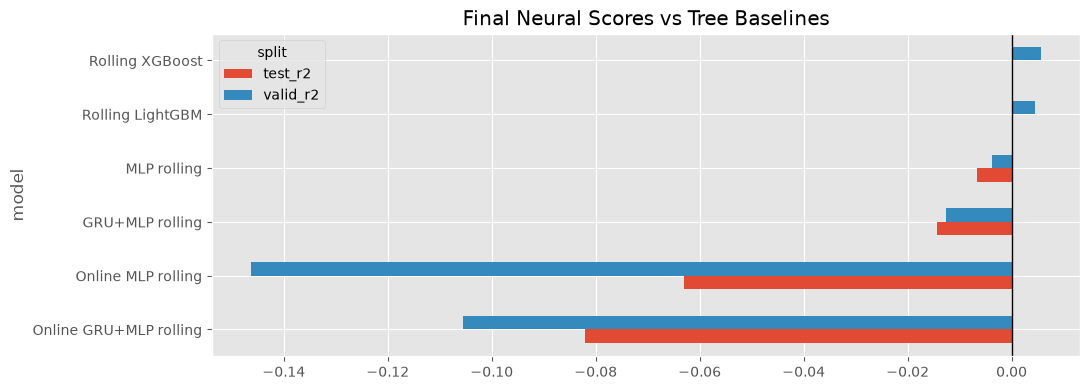

In [6]:
plot_scores = score_df.melt(
    id_vars=["model"],
    value_vars=["valid_r2", "test_r2"],
    var_name="split",
    value_name="weighted_r2",
).dropna()

grouped_barh(plot_scores, "model", "weighted_r2", "split", "Final Neural Scores vs Tree Baselines")


,model,split,date_id,rows,weighted_r2
60,Online GRU+MLP rolling,test,1510,34028,-0.166160
61,Online GRU+MLP rolling,test,1511,35100,-0.076458
62,Online GRU+MLP rolling,test,1512,35100,-0.087702
63,Online GRU+MLP rolling,test,1513,34200,-0.041732
64,Online GRU+MLP rolling,test,1514,35100,-0.100700
65,Online GRU+MLP rolling,test,1515,35096,-0.057567
66,Online GRU+MLP rolling,test,1516,34831,-0.180320
67,Online GRU+MLP rolling,test,1517,35100,-0.066517
68,Online GRU+MLP rolling,test,1518,35100,-0.029530
69,Online GRU+MLP rolling,test,1519,35100,-0.083436


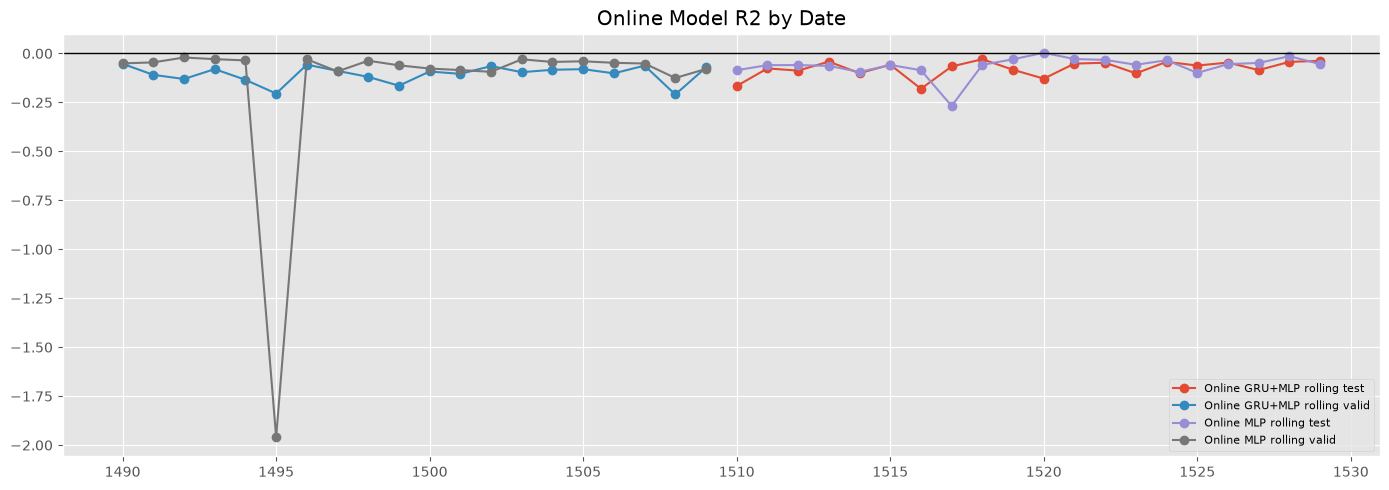

In [7]:
date_frames = []
for model, report in reports.items():
    date_scores = report.get("date_scores", [])
    if date_scores:
        df = pd.DataFrame(date_scores)
        df.insert(0, "model", model)
        date_frames.append(df)

date_df = pd.concat(date_frames, ignore_index=True) if date_frames else pd.DataFrame()

if not date_df.empty:
    fig, ax = plt.subplots(figsize=(14, 5))
    for (model, split), group in date_df.groupby(["model", "split"]):
        group = group.sort_values("date_id")
        ax.plot(group["date_id"], group["weighted_r2"], marker="o", label=f"{model} {split}")
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title("Online Model R2 by Date")
    ax.legend(fontsize=8)
    plt.tight_layout()

date_df.tail(20)


## Notes

The neural models overfit quickly: training loss falls, but validation R2 gets worse after the first epoch. Online updates are unstable in this setup and perform worse than the static neural models.


## Regularized MLP Sweep

Comparison of network size, MSE versus Huber loss, embeddings, dropout, weight decay, early stopping, and prediction shrinkage.


,model,valid_weighted_r2,test_weighted_r2,best_epoch,best_shrink,model_path,name,dropout,lr,weight_decay,loss,use_embeddings,hidden,huber_delta
0,small_no_embed,0.005661,0.001942,3,0.75,/users/s/a/sakshay/js_kaggle/models/neural/reg...,small_no_embed,0.25,0.0003,0.001,mse,False,"[128, 64]",NaN
1,small_huber,0.005396,0.001465,5,0.75,/users/s/a/sakshay/js_kaggle/models/neural/reg...,small_huber,0.30,0.0003,0.001,huber,True,"[128, 64]",0.5
2,small_mse,0.005264,0.002715,4,0.75,/users/s/a/sakshay/js_kaggle/models/neural/reg...,small_mse,0.25,0.0003,0.001,mse,True,"[128, 64]",NaN
3,tiny_mse,0.004512,0.001730,5,0.50,/users/s/a/sakshay/js_kaggle/models/neural/reg...,tiny_mse,0.20,0.0003,0.001,mse,True,"[64, 32]",NaN
4,linear_strong_decay,0.003293,0.000922,5,0.50,/users/s/a/sakshay/js_kaggle/models/neural/reg...,linear_strong_decay,0.00,0.0001,0.010,huber,True,[],0.5


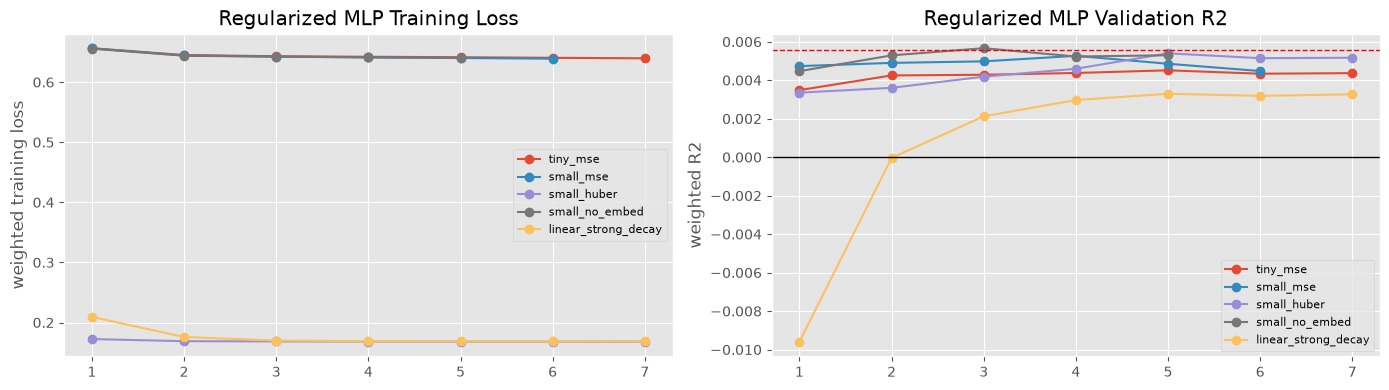

In [8]:
if SWEEP_HISTORY_PATH.exists() and SWEEP_SUMMARY_PATH.exists():
    sweep_history = pd.read_csv(SWEEP_HISTORY_PATH)
    sweep_summary = pd.read_csv(SWEEP_SUMMARY_PATH).sort_values("valid_weighted_r2", ascending=False)

    display(sweep_summary)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_grouped_lines(axes[0], sweep_history, "epoch", "train_loss", "model")
    axes[0].set_title("Regularized MLP Training Loss")
    axes[0].set_ylabel("weighted training loss")

    plot_grouped_lines(axes[1], sweep_history, "epoch", "best_shrunk_valid_weighted_r2", "model")
    axes[1].axhline(0, color="black", linewidth=1)
    axes[1].axhline(BASELINE_SCORES["Rolling XGBoost"], color="red", linestyle="--", linewidth=1)
    axes[1].set_title("Regularized MLP Validation R2")
    axes[1].set_ylabel("weighted R2")
    plt.tight_layout()
else:
    print("Regularized MLP sweep outputs not found yet.")


## Focused Regularized MLP Sweep

Repeated-seed comparison of the strongest regularized MLP configurations, used to separate stable gains from favorable initialization.


,model,valid_weighted_r2,test_weighted_r2,best_epoch,best_shrink,model_path,base_name,seed,dropout,lr,weight_decay,use_embeddings,hidden
0,small_no_embed_more_dropout_seed202,0.005736,0.002365,4,0.75,/users/s/a/sakshay/js_kaggle/models/neural/reg...,small_no_embed_more_dropout,202,0.35,0.0003,0.001,False,"[128, 64]"
1,small_no_embed_more_decay_seed202,0.005565,0.002644,4,0.60,/users/s/a/sakshay/js_kaggle/models/neural/reg...,small_no_embed_more_decay,202,0.25,0.0003,0.003,False,"[128, 64]"
2,small_no_embed_seed202,0.005564,0.002643,4,0.60,/users/s/a/sakshay/js_kaggle/models/neural/reg...,small_no_embed,202,0.25,0.0003,0.001,False,"[128, 64]"
3,small_no_embed_more_dropout_seed777,0.005543,0.002384,4,0.75,/users/s/a/sakshay/js_kaggle/models/neural/reg...,small_no_embed_more_dropout,777,0.35,0.0003,0.001,False,"[128, 64]"
4,small_mse_seed777,0.005503,0.002163,6,0.60,/users/s/a/sakshay/js_kaggle/models/neural/reg...,small_mse,777,0.25,0.0003,0.001,True,"[128, 64]"
5,small_no_embed_more_dropout_seed42,0.005498,0.003465,4,0.75,/users/s/a/sakshay/js_kaggle/models/neural/reg...,small_no_embed_more_dropout,42,0.35,0.0003,0.001,False,"[128, 64]"
6,small_mse_seed202,0.005464,0.002547,3,0.75,/users/s/a/sakshay/js_kaggle/models/neural/reg...,small_mse,202,0.25,0.0003,0.001,True,"[128, 64]"
7,small_no_embed_more_decay_seed777,0.005452,0.002599,4,0.75,/users/s/a/sakshay/js_kaggle/models/neural/reg...,small_no_embed_more_decay,777,0.25,0.0003,0.003,False,"[128, 64]"
8,small_no_embed_seed777,0.005451,0.002598,4,0.75,/users/s/a/sakshay/js_kaggle/models/neural/reg...,small_no_embed,777,0.25,0.0003,0.001,False,"[128, 64]"
9,small_mse_low_lr_seed777,0.005432,0.001734,7,0.75,/users/s/a/sakshay/js_kaggle/models/neural/reg...,small_mse_low_lr,777,0.25,0.0001,0.001,True,"[128, 64]"


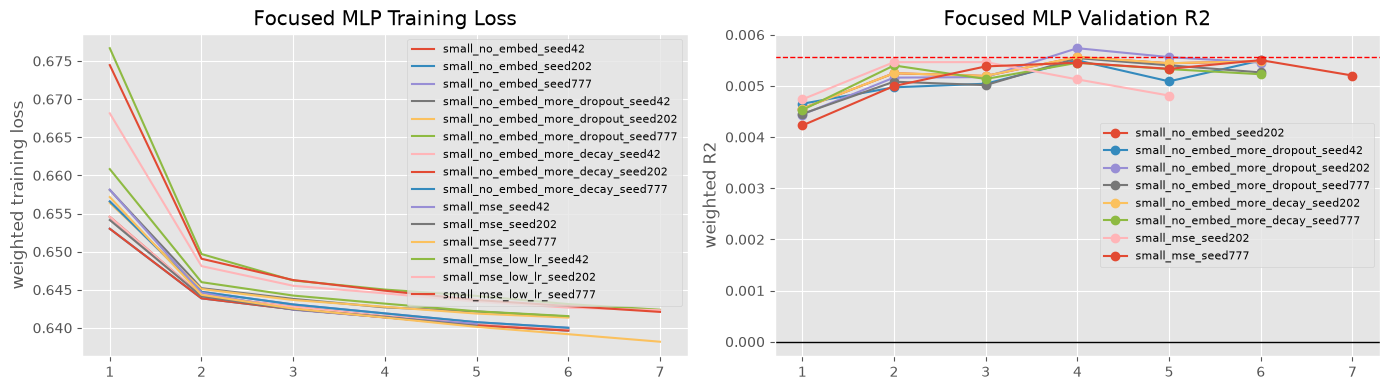

In [9]:
FOCUSED_DIR = PROJECT_ROOT / "models" / "neural" / "regularized_mlp_focused"
FOCUSED_HISTORY_PATH = FOCUSED_DIR / "history.csv"
FOCUSED_SUMMARY_PATH = FOCUSED_DIR / "summary.csv"

if FOCUSED_HISTORY_PATH.exists() and FOCUSED_SUMMARY_PATH.exists():
    focused_history = pd.read_csv(FOCUSED_HISTORY_PATH)
    focused_summary = pd.read_csv(FOCUSED_SUMMARY_PATH).sort_values("valid_weighted_r2", ascending=False)
    display(focused_summary.head(20))

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_grouped_lines(axes[0], focused_history, "epoch", "train_loss", "model", marker="", max_groups=15)
    axes[0].set_title("Focused MLP Training Loss")
    axes[0].set_ylabel("weighted training loss")

    top_models = focused_summary.head(8)["model"].tolist()
    plot_hist = focused_history[focused_history["model"].isin(top_models)]
    plot_grouped_lines(axes[1], plot_hist, "epoch", "best_shrunk_valid_weighted_r2", "model")
    axes[1].axhline(0, color="black", linewidth=1)
    axes[1].axhline(BASELINE_SCORES["Rolling XGBoost"], color="red", linestyle="--", linewidth=1)
    axes[1].set_title("Focused MLP Validation R2")
    axes[1].set_ylabel("weighted R2")
    plt.tight_layout()
else:
    print("Focused MLP sweep outputs not found yet.")


## Final Neural Experiment Summary

The first neural models overfit quickly: training loss improved, but validation R2 fell below zero. We then tested regularization changes to identify what helped.


,experiment,model,split,weighted_r2
21,ensemble_focused_mlp_xgb,ensemble,valid,0.006523
20,ensemble_focused_mlp_xgb,focused_mlp_mean,valid,0.005984
15,ensemble_all_neural,ensemble,valid,0.005796
2,regularized_mlp_focused,small_no_embed_more_dropout_seed202,valid,0.005736
0,regularized_mlp_sweep,small_no_embed,valid,0.005661
4,ensemble_all_neural,xgb,test,0.004996
16,ensemble_focused_mlp_xgb,xgb,test,0.004996
19,ensemble_focused_mlp_xgb,xgb,valid,0.004963
9,ensemble_all_neural,xgb,valid,0.004963
14,ensemble_all_neural,ensemble,test,0.004597


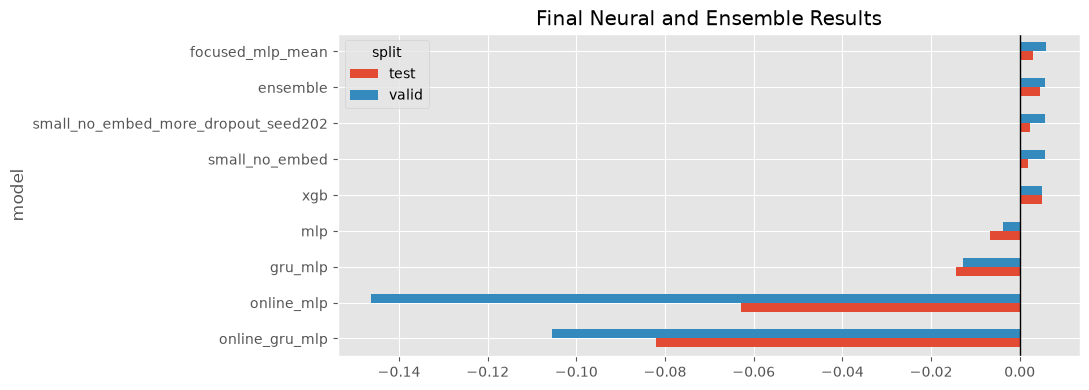

In [10]:
FINAL_REPORTS = {
    "regularized_mlp_sweep": LOG_DIR / "train_regularized_mlp_sweep_report.json",
    "regularized_mlp_focused": LOG_DIR / "train_regularized_mlp_focused_report.json",
    "ensemble_all_neural": LOG_DIR / "ensemble_rolling_report.json",
    "ensemble_focused_mlp_xgb": LOG_DIR / "ensemble_focused_mlp_xgb_report.json",
}

final_rows = []
for name, path in FINAL_REPORTS.items():
    if not path.exists():
        print(f"missing: {path}")
        continue
    report = json.loads(path.read_text())
    if "scores" in report:
        for row in report["scores"]:
            final_rows.append({
                "experiment": name,
                "model": row["model"],
                "split": row["split"],
                "weighted_r2": row["weighted_r2"],
            })
    elif "best" in report:
        best = report["best"]
        final_rows.append({
            "experiment": name,
            "model": best.get("model", best.get("name")),
            "split": "valid",
            "weighted_r2": best.get("valid_weighted_r2"),
        })
        final_rows.append({
            "experiment": name,
            "model": best.get("model", best.get("name")),
            "split": "test",
            "weighted_r2": best.get("test_weighted_r2"),
        })

final_df = pd.DataFrame(final_rows).dropna(subset=["weighted_r2"])
display(final_df.sort_values("weighted_r2", ascending=False))

if not final_df.empty:
    grouped_barh(final_df, "model", "weighted_r2", "split", "Final Neural and Ensemble Results")


## What Worked

- Smaller MLPs worked better than the initial larger MLP.
- Stronger dropout and weight decay reduced overfitting.
- LayerNorm was more stable than the original BatchNorm setup.
- Prediction shrinkage helped validation R2.
- Removing symbol/time embeddings helped several runs.
- Averaging focused MLP seeds improved validation.

## What Did Not Work

- The first MLP and GRU+MLP overfit immediately.
- Online updates made validation/test performance worse.
- GRU+MLP was not useful in this setup.
- Focused MLP ensembles improved validation but did not beat rolling XGBoost on test.

## Final Takeaway

The best validation model was the focused MLP + XGBoost ensemble, but the strongest test model remained rolling XGBoost.
